# Tissue simulation, in depth — 1: building tissue & the monodomain engine

Chapter 1 ran a tissue simulation but kept the setup in a black box: "make a strip, give it
conductivity, put an electrode on the edge, run it." This chapter opens that box. By the end of these
three notebooks you will know what every piece is, be able to change it on purpose, and read the number
that matters most — the **conduction velocity**, how fast the wave travels.

This first notebook builds the tissue from scratch — the **grid**, the **conductivity**, the
**stimulus**, and a **scar** — and runs it on the default engine, **monodomain**. The next two
(3.2 and 3.3) reuse this exact setup and swap in the other two engines.

**What you'll learn**

1. **The grid** — the shape and size of the tissue, and how spacing sets its physical dimensions
2. **Conductivity** — how well the tissue passes current, and the diffusivity it implies
3. **The stimulus** — where you place the electrode, and how that decides which way the wave goes
4. **The monodomain engine** — assemble, run, watch the wave, and measure its speed
5. **A scar** — carve out dead tissue with a mask and watch the wave route around it

**Runtime**: about 20 seconds of computing (two short tissue runs). On Google Colab, add about a minute
the first time for the install.

---
## 0. Install and import

Same one-time setup as Chapter 1: install `cardiac_core` if this environment doesn't already have it,
then import it under the short name `cc`.

In [1]:
# Installs cardiac_core if this environment doesn't already have it (e.g. a fresh Colab runtime).
# If it is already installed, this does nothing.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("cardiac_core") is None:
    print("Installing cardiac_core — this takes about a minute, please wait...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "cardiac-core[viz] @ git+https://github.com/RealJokerInc/cardiac-core.git"],
        check=True,
    )
    print("Installed.")
else:
    print("cardiac_core is already available.")

cardiac_core is already available.


In [2]:
import cardiac_core as cc

print("cardiac_core is ready")

cardiac_core is ready


---
## 1. The grid — the shape of the tissue

A simulation needs a piece of tissue to run on, and `cardiac_core` represents it as a **grid**: a
regular lattice of points (called *nodes*), evenly spaced. You describe it with three numbers:

- **`Nx`** — how many nodes across (the x direction),
- **`Ny`** — how many nodes tall (the y direction),
- **`dx`** — the spacing between neighbouring nodes, **in centimetres**.

The physical *size* of the tissue is not something you set directly — it follows from the node count
and the spacing. With `Nx` nodes spaced `dx` apart there are `Nx - 1` gaps between them, so the width is

    Lx = dx * (Nx - 1)

Build a 1.0 cm × 0.3 cm strip: 101 nodes across at 0.01 cm spacing gives `0.01 × 100 = 1.0` cm, and
31 nodes tall gives `0.01 × 30 = 0.3` cm.

In [3]:
g = cc.Grid(101, 31, 0.01)      # Nx=101 nodes across, Ny=31 tall, dx=0.01 cm spacing

print(f"nodes      : {g.Nx} across x {g.Ny} tall")
print(f"spacing dx : {g.dx} cm")
print(f"size       : {g.Lx} cm wide x {g.Ly} cm tall")

nodes      : 101 across x 31 tall
spacing dx : 0.01 cm
size       : 1.0 cm wide x 0.3 cm tall


So `g` is a strip of heart tissue 1 cm long and 3 mm tall, sampled at 3131 points. The spacing `dx`
is not just cosmetic: it is how finely the tissue is resolved, and Chapter 5 shows that too coarse a
`dx` gives a *wrong* conduction velocity. 0.01 cm (0.1 mm) is a safe, standard choice — keep it for now.

### Try it yourself

Make the strip **twice as long** without changing how finely it is sampled: change `101` to `201` and
re-run the cell. The width `Lx` should become 2.0 cm while `dx` stays 0.01 cm. (Changing `dx` instead
would rescale the tissue *and* the resolution — a different kind of change, and the subject of Chapter 5.)

---
## 2. Conductivity — how well the tissue conducts

The wave spreads because each excited patch of tissue drives current into its neighbours, nudging them
to fire in turn. **Conductivity** is how freely that current flows. You set it with a
`ConductivityConfig`, and the most physical constructor is `.bidomain(sigma_i, sigma_e)`, which takes
two conductivities — one for the space *inside* the cells (`sigma_i`, intracellular) and one for the
space *between* them (`sigma_e`, extracellular), both in **mS/cm**.

The values below, `sigma_i = 1.74` and `sigma_e = 6.25`, are standard numbers for healthy human
ventricle. From them the library derives a single **effective diffusivity** `D_eff` — the quantity that
actually sets how fast the wave moves. You don't compute it by hand; it's there to look at.

In [4]:
cond = cc.ConductivityConfig.bidomain(1.74, 6.25)   # healthy human ventricle, mS/cm

print(f"effective conductivity : {cond.sigma_eff:.3f} mS/cm")
print(f"effective diffusivity  : {cond.D_eff:.6f} cm^2/ms")

effective conductivity : 1.361 mS/cm
effective diffusivity  : 0.000972 cm^2/ms


The two conductivities combine into an effective conductivity of about **1.36 mS/cm** and a
diffusivity of about **0.00097 cm²/ms**. You will feel the effect of this number directly in
Chapter 5: lower conductivity means weaker coupling — a slower, more fragile wave, the situation in
fibrotic or diseased tissue — and the wave speed scales with the square root of it.

For now, take these healthy values as given and move on to the last ingredient: the electrode.

---
## 3. The stimulus — where you put the electrode

A resting sheet of tissue sits still forever. To start a beat you have to poke it — inject a little
current somewhere to push the first cells over threshold. That poke is the **stimulus**, and you can
think of it as *where you place the electrode*. `cardiac_core` gives you a `Stim` object with a few
ready-made placements:

| Placement | What it is | The wave it launches |
|---|---|---|
| `cc.Stim.boundary(g, "left")` | a line electrode along a whole edge (`"left"`/`"right"`/`"top"`/`"bottom"`) | a flat wave marching across, straight-on |
| `cc.Stim.point(g, (x, y))` | a small dot electrode at one `(x, y)` spot | a round wave spreading outward from that point |
| `cc.Stim.center(g)` | a dot at the middle of the tissue | a round wave from the centre |

Besides *where*, a stimulus has a *when* and a *how hard*: `start_time` (ms), `duration` (ms), and
`amplitude` (in µA/µF — **negative means depolarising**, i.e. it excites the tissue; −52 is a typical
strong-enough value). Here we place a line electrode along the left edge, firing at 1 ms for 2 ms.

In [5]:
stim = cc.Stim.boundary(
    g, "left",            # a line electrode down the whole left edge
    amplitude=-52.0,      # uA/uF; negative = depolarising (excitatory)
    start_time=1.0,       # fire at t = 1 ms
    duration=2.0,         # hold for 2 ms
)

print(f"the electrode covers {stim.n_nodes()} nodes ({stim.mode} mode)")

the electrode covers 62 nodes (current mode)


The left-edge electrode touches 62 nodes — the whole left column. Because it fires the entire edge
at once, it launches a flat wavefront that will march straight across the strip, left to right. Put the
electrode somewhere else and the wave starts somewhere else, as the "Try it yourself" at the end of the
next section shows.

That's the full cast: a **grid**, a **conductivity**, and a **stimulus**. Time to run it.

---
## 4. The monodomain engine — run it and measure the wave

An **engine** is the numerical method that actually solves the physics of propagation.
`cardiac_core` has three; the default and fastest is **monodomain**, which tracks a single voltage at
each node. (The other two are the subjects of 3.2 and 3.3.) You build a simulation by handing the
engine the four pieces — grid, ionic model, conductivity, stimulus — plus a time step `dt`:

In [6]:
sim = cc.monodomain(g, "ttp06", cond, stim, dt=0.05)   # assemble: grid, cell model, conductivity, electrode
r = sim.run(t_end=30.0, save_every=0.5)                # run 30 ms, keep a frame every 0.5 ms

print("done — the wave has crossed the strip")

done — the wave has crossed the strip


`"ttp06"` is the ionic model — the cell machinery from Chapter 1 — and `dt=0.05` ms is the time
step (smaller is more accurate but slower; 0.05 is plenty here). The run returns a **result** `r` that
holds the voltage everywhere at every saved moment and knows how to draw itself. Watch the wave:

In [7]:
r.video()   # an inline movie of the excitation wave sweeping left to right

VideoInfo(path=None, n_frames=60, fps=20.0, backend='imageio-ffmpeg', codec='libx264', width=1920, height=1080, duration_s=3.0, vmin=-90.0, vmax=40.0, stride=1, size_bytes=112427, bitrate=None)

A bright band enters from the left edge — where the electrode fired — and sweeps to the right, each
patch of tissue exciting the next. Freeze it partway across, at 12 ms:

ImageInfo(unsaved, 1077x448, panels=1, range=(-90.0, 40.0), 25,602 bytes)
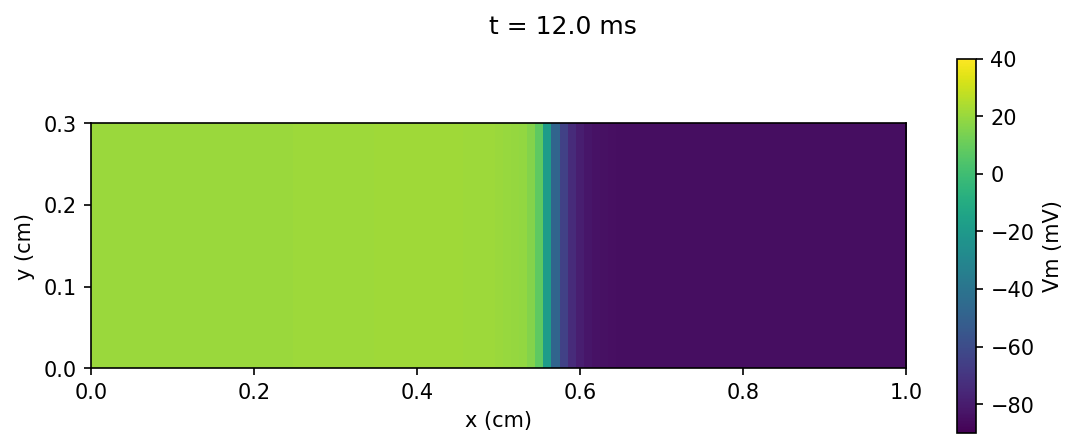

In [8]:
r.image(at=12.0)   # snapshot of the membrane voltage at t = 12 ms

The bright front sits around the middle of the strip: 12 ms after the left edge fired, the wave has
crossed about half of the 1 cm. Everything behind it is excited; everything ahead is still resting.

Now the most useful single view — the **activation map**. Instead of one instant, it colours every
node by *when* the wave first reached it, and draws contour lines (**isochrones**) connecting points
that activated at the same time:

ImageInfo(unsaved, 1079x412, panels=1, range=(2.5, 19.1), 26,632 bytes)
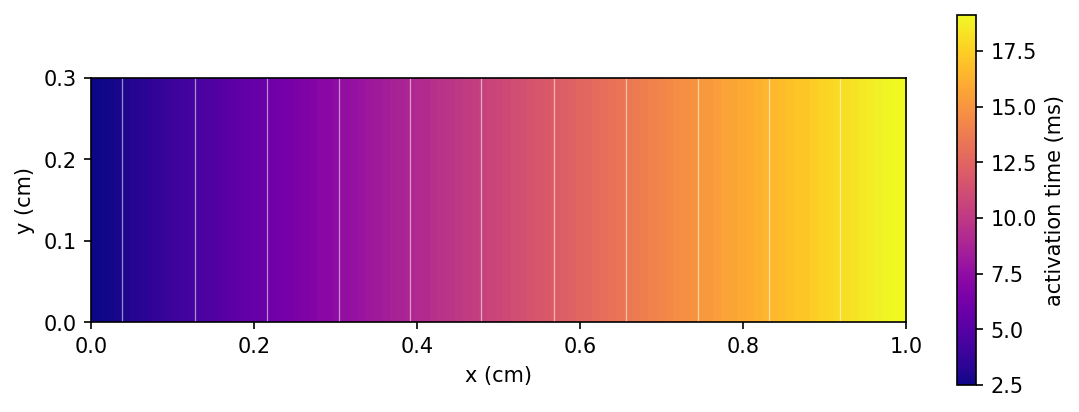

In [9]:
r.image(what="activation")   # colour each node by the time the wave arrived

The isochrones are straight, vertical, and evenly spaced — the signature of a flat wave crossing at
a steady speed. Evenly spaced contours mean equal time for equal distance, which is exactly what
constant velocity looks like. And that velocity is a number you can pull straight out of the result:

In [10]:
cv = r.cv(x1=20, x2=80, y=15)   # conduction velocity between two x-columns, along the middle row
print(f"conduction velocity = {cv:.1f} cm/s")

conduction velocity = 58.5 cm/s


**About 58 cm/s** — squarely in the healthy human-ventricle range (roughly 50–70 cm/s). That is
the headline measurement of a tissue simulation and the number Chapter 5 spends its time tuning.

`r.cv(x1=20, x2=80, y=15)` measures it the honest way: it takes the time the wave arrived at column 20
and at column 80 (both well inside the strip, away from edge effects), and divides the distance between
them by that time difference, reading along the middle row `y=15`. Remember this exact call — 3.2 and
3.3 measure their engines the same way so the numbers can be compared fairly.

### Try it yourself

Move the electrode. Go back to the `cc.Stim.boundary(...)` cell in section 3, change `"left"` to
`"bottom"`, and re-run from there down. The flat wave now marches *upward* instead of rightward — watch
the video and the activation map turn. For a different shape entirely, try
`cc.Stim.center(g, amplitude=-52.0, start_time=1.0, duration=2.0)`: a round wave spreads outward from
the middle, and the isochrones become curved rings instead of straight lines.

---
## 5. A scar — carving dead tissue with a mask

Real hearts have damage: patches of scar where cells have died and no longer conduct. You model one by
picking out a region of the grid with a **mask** and setting its diffusivity to zero, so no current can
flow through it. Two helpers build the region:

- `cc.rectangle_mask(Nx, Ny, dx, x0, y0, x1, y1)` — a rectangle, corners in **cm**,
- `cc.circle_mask(Nx, Ny, dx, center, radius)` — a disc.

Here we place a rectangular scar in the middle of the strip — spanning most of its height but leaving a
gap at the top and bottom — and make it inexcitable with `sim.set_conductivity(mask, D=0.0)`:

In [11]:
sim = cc.monodomain(g, "ttp06", cond, stim, dt=0.05)
scar = cc.rectangle_mask(101, 31, 0.01, 0.4, 0.08, 0.6, 0.22)   # a block in the middle (corners in cm)
sim.set_conductivity(scar, D=0.0)                                # D=0 -> dead tissue, no current flows

r_scar = sim.run(t_end=30.0, save_every=0.5)
print(f"the scar blocks {int(scar.sum())} nodes")

the scar blocks 315 nodes


Watch what the wave does now:

ImageInfo(unsaved, 1079x412, panels=1, range=(2.5, 19.6), 39,712 bytes)
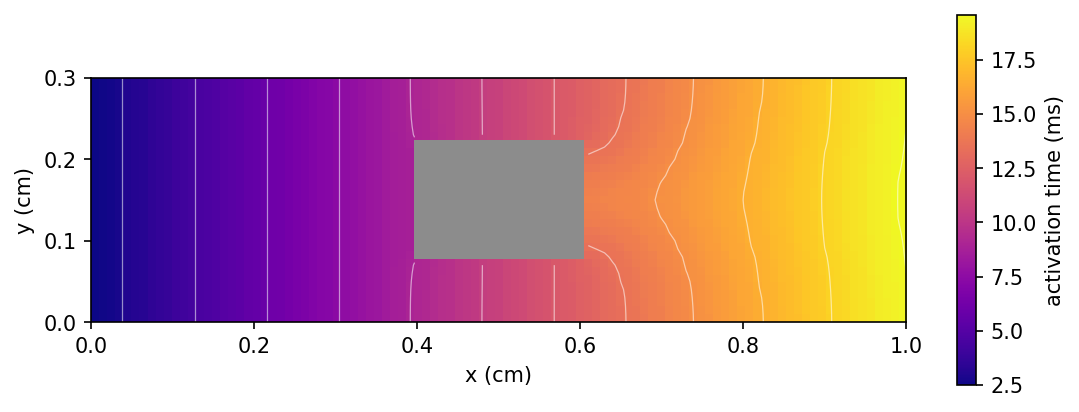

In [12]:
r_scar.image(what="activation")   # activation map with the scar in place

The scar is the blank patch in the middle — it never activates, so it has no arrival time to
colour. The isochrones, straight before, now **bend around** it: the wave can't go through, so it
splits and travels through the narrow channels above and below, then closes back together on the far
side. The two halves meet just past the scar, where the contour lines pinch inward. That detour is
exactly how a scar reshapes conduction in a real heart — and, squeeze the channel narrow enough, the
wave can fail to get through at all (**conduction block**), which is where Chapter 5 picks up.

### Try it yourself

Swap the rectangle for a round scar. Replace the `scar = ...` line with

    scar = cc.circle_mask(101, 31, 0.01, center=(0.5, 0.15), radius=0.08)

and re-run the two cells. The wave now bows smoothly around a disc instead of squeezing past a block —
the activation map shows the isochrones curving around it and rejoining behind.

---
## 6. Advanced — how the grid handles the wall

*(A peek under the hood. Skip it if you just want to build tissue — the defaults are sensible.)*

Look back at the activation maps: the isochrones ran dead straight, all the way to the top and bottom
edges. That is not automatic. It depends on two low-level choices about how the grid is wired, and
changing them can make the wave **bend at the wall**. Both are the subject of an active research
question in this lab — *boundary conduction speedup* — and here is the shortest possible tour.

**The stencil — who each node listens to.** Every node updates from its neighbours. The default,
`cardinal4`, listens to the **4** face-neighbours (up, down, left, right): the classic "4-point"
stencil. But real muscle is also coupled to its **diagonal** neighbours, so `cardiac_core` also offers
a **9-point** stencil, `moore8`, that adds the four diagonals. You pick with `stencil=`.

**The wall handling — what sits just outside the tissue.** At a no-flux wall the solver invents a
"ghost" value just past the edge. The **standard** rule (`face_mirror`) mirrors the edge node's own
value; an alternative, **iso-mirror** (`face_mirror_iso`), fills the diagonal ghost from the neighbour
one row in. On the **4-point** stencil these are identical — there are no diagonals for them to disagree
about, which is exactly why the wave above stayed straight. On the **9-point** stencil they part ways.

Run the same wave on a square sheet with the 9-point stencil, once with each wall rule:

ImageInfo(unsaved, 1112x1041, panels=1, range=(1.5, 20.0), 72,556 bytes)
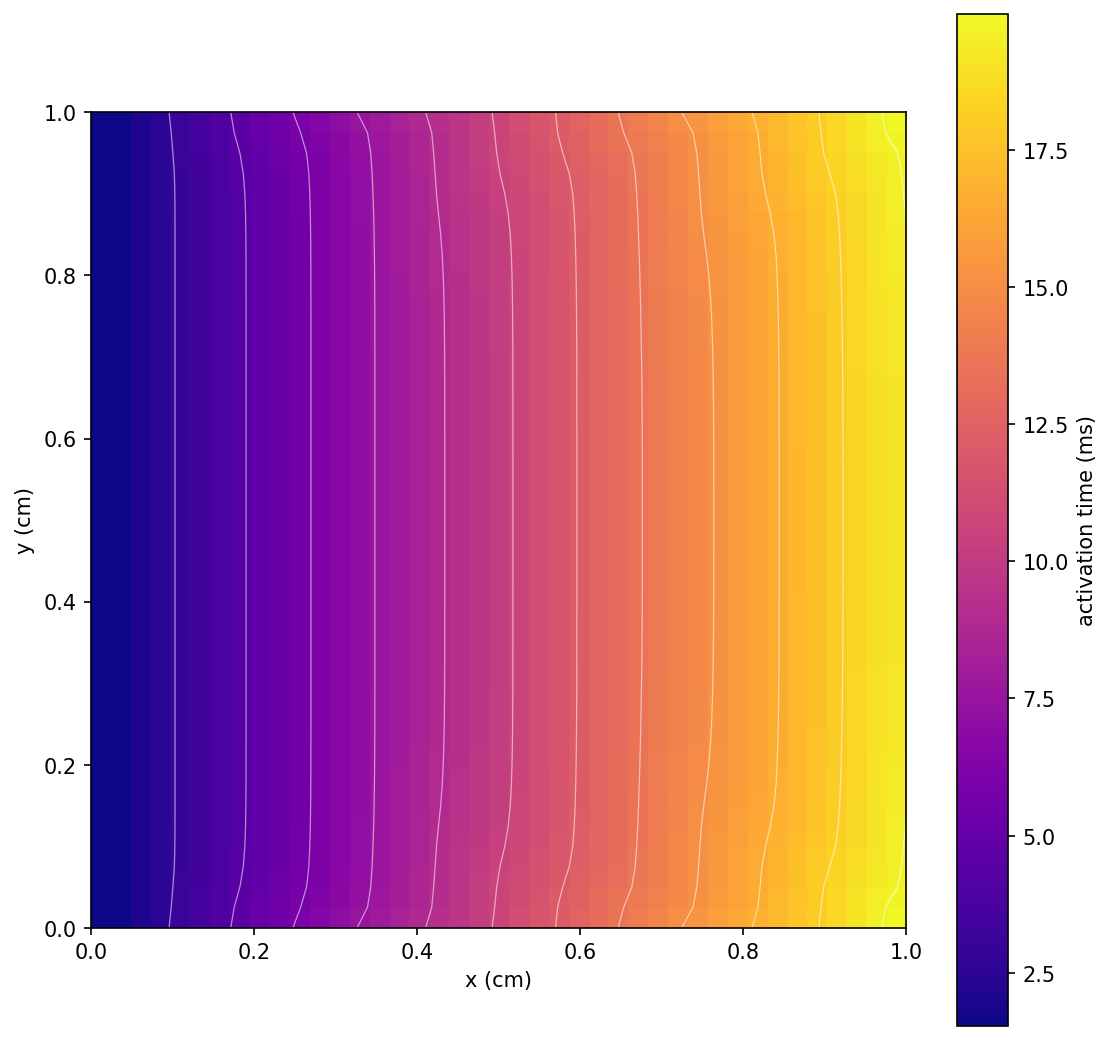

In [13]:
gb    = cc.Grid(41, 41, 0.025)                       # a 1 x 1 cm sheet; top & bottom are the walls
iso   = cc.ConductivityConfig.isotropic(1.4)         # Moore-8 needs isotropic tissue with dx = dy
stimb = cc.Stim.boundary(gb, "left", amplitude=-80.0, start_time=1.0, duration=2.0)

# same tissue, same wave — only the WALL RULE differs:
r_std = cc.monodomain(gb, "ttp06", iso, stimb, stencil="moore8_uniform",
                      boundary_mode="face_mirror").run(t_end=45.0, save_every=0.5)      # standard wall
r_iso = cc.monodomain(gb, "ttp06", iso, stimb, stencil="moore8_uniform",
                      boundary_mode="face_mirror_iso").run(t_end=45.0, save_every=0.5)  # iso-mirror wall

r_std.image(what="activation")

With the **standard** wall rule the isochrones no longer meet the top and bottom edges straight —
they **bow backward** there. The wave reaches the walls *later* than the middle: a shape called a
**forward crescent**, a genuine **boundary slowdown** (about **0.5 ms** of lag at the wall here). The
cause is mechanical — `face_mirror` zeroes the diagonal flux right at the wall, so the edge nodes'
diagonal channels are starved of upstream signal and charge more slowly than the interior.

The same run with the **iso-mirror** rule:

ImageInfo(unsaved, 1092x1041, panels=1, range=(1.5, 19.2), 33,016 bytes)
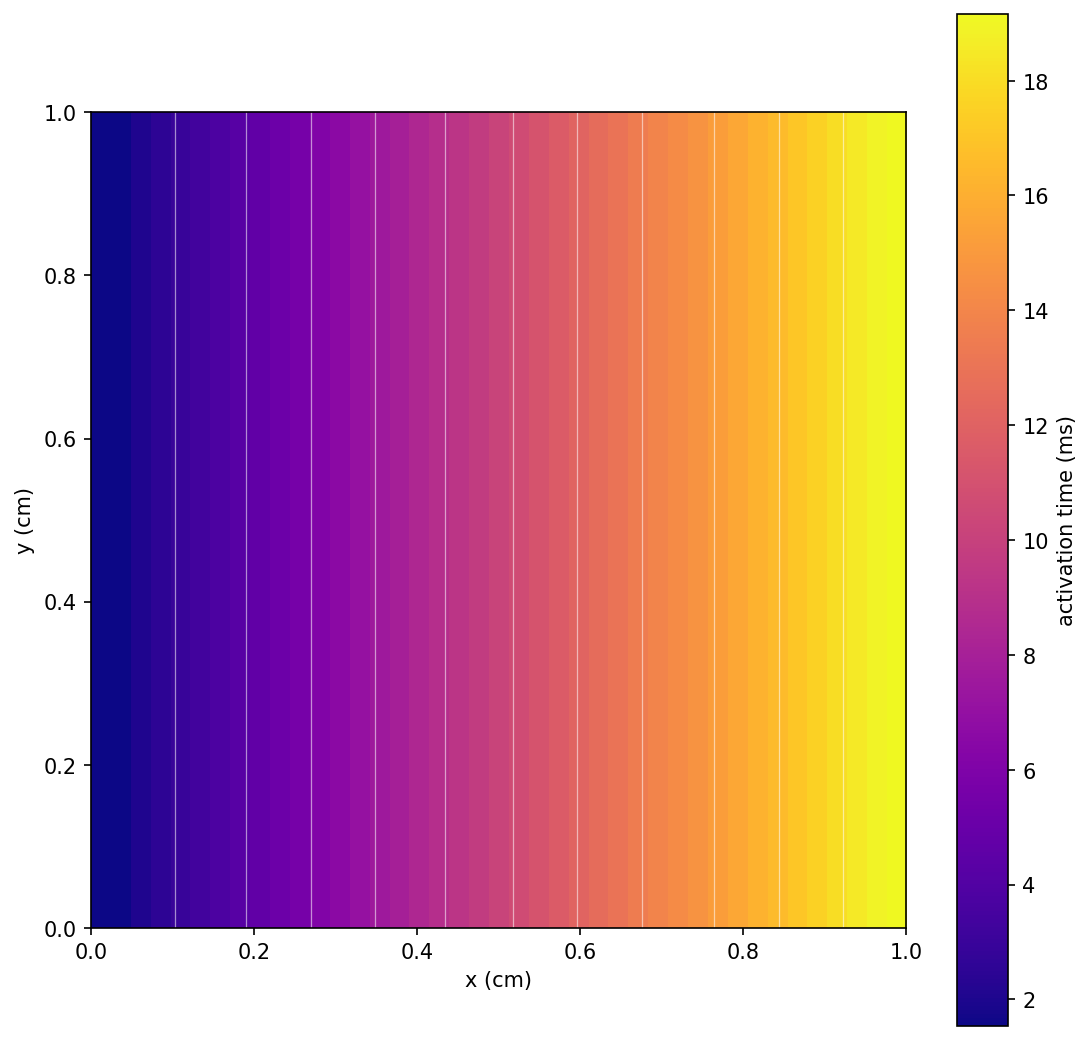

In [14]:
r_iso.image(what="activation")   # same tissue, only the wall rule changed

Straight again. `face_mirror_iso` feeds the missing diagonal from the real neighbour one row in,
so the wall charges at the interior rate and the crescent vanishes. And the **4-point** default
(`cardinal4`) shows *no* wall effect at all — with no diagonals to starve, the two wall rules are
identical. That is this notebook's real control: **no diagonals, no boundary bias.**

⚠️ One footgun: `face_mirror_iso` does nothing on the default `cardinal4` stencil — to see it change
anything you must *also* pass `stencil="moore8_uniform"`.

Watch the slowed wave curl back at the walls as it crosses:

In [15]:
r_std.video()   # the front bowing backward at the top and bottom walls

VideoInfo(path=None, n_frames=90, fps=20.0, backend='imageio-ffmpeg', codec='libx264', width=1920, height=1080, duration_s=4.5, vmin=-90.0, vmax=40.0, stride=1, size_bytes=248717, bitrate=None)

That the wavefront's *shape at a boundary* depends on discretisation choices — the stencil, the
ghost-cell rule — is the heart of the **boundary conduction speedup** research. For the full argument
(why the diagonals are the prerequisite, and how the very same wall handling can produce a boundary
**speedup** instead of a slowdown), see **Li Chang's May 2026 progress report**. We pick this thread
back up — and meet that speedup — in **Notebook 3.3 (LBM)**.

---
## Recap

- A tissue simulation is built from a **grid** (`cc.Grid(Nx, Ny, dx)` — size is `dx*(Nx-1)` in cm), a
  **conductivity** (`cc.ConductivityConfig.bidomain(...)`, which sets the diffusivity), and a
  **stimulus** (`cc.Stim.boundary/point/center` — *where you put the electrode*).
- Hand those to the **monodomain** engine, `.run()` it, and the **result** draws itself — `r.video()`,
  `r.image(at=...)`, `r.image(what="activation")` — and measures itself: `r.cv(x1, x2, y)` gave
  **≈ 58 cm/s** on healthy tissue.
- A **mask** plus `sim.set_conductivity(mask, D=0.0)` carves an inexcitable **scar**, and the wave
  routes around it.

**Where next**: Notebook 3.2 keeps this exact strip and swaps in the **bidomain** engine, which tracks
a second potential — the one *outside* the cells — and shows you what that extra field buys you. Then
3.3 runs the same strip on the **LBM** engine, a completely different numerical route, and explains why
its speed comes out a little different.